# Make a plot of just the PCA \delta T profile

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import corner, h5py, os, glob, re, io, subprocess, tempfile
import emcee
from scipy.stats import gaussian_kde, ks_2samp
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve
from IPython.display import display, Image
import warnings
import os.path as osp
warnings.filterwarnings('ignore')
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

import sys
sys.path.insert(0, os.path.expanduser('~/DIB'))
from MCMC_convergence_tests import detect_multimodal, ks_stability_test, compute_rhat, format_diagnostics

# ── Matplotlib style ──────────────────────────────────────────────────────────
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)
plt.rc('axes', linewidth=1.5)
plt.rc('xtick', labelsize=11, direction='in', top=True)
plt.rc('ytick', labelsize=11, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=6, pad=4)
plt.rc('xtick.minor', size=3)
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=3)
plt.rc('legend', fontsize=10)
import datetime
import pandas as pd
from scipy.stats import chi2 as chi2_dist


## 1  User Configuration

In [2]:
# ════════════════════════════════════════════════════════════════════════════
#  FILE SELECTION
#   Set file_override = '/full/path/to/backend.h5' to pin a specific file.
#   Otherwise the script lists all matching files and picks file_index.
# ════════════════════════════════════════════════════════════════════════════

backend_dir =  osp.expanduser("~/../../scratch/gpfs/MELCHIOR/cj1223/DIB") 
dib_band       = '15272'   # '15272' or '15672'
symmetry_group = 'Cs'    # 'C2v'  or 'Cs'
file_index     = 2   # which matching file to load (0 = most recently modified)
file_override  = None      # str path or None
# file_override = backend_dir + '/' + '15672_run_DIB15672_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errPlate_trunc10_balanceErrTrue_dTcenterNone_centeroffset0p15_test.h5'
file_override = backend_dir + '/' + '15272_run_DIB15272_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p05_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,3p0,2p0]_centeroffset0p01_sweep.h5'
# file_override = backend_dir + '/' + 'bc_run_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_update.h5'
# file_override = backend_dir + '/' + '15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errDefault_trunc0_balanceErrFalse_dTcenter[10p0,3p0,-2p0]_centeroffset0p1_sweep.h5'


# ════════════════════════════════════════════════════════════════════════════
#  ANALYSIS OPTIONS
# ════════════════════════════════════════════════════════════════════════════
save_fig           = False  # also save figures to disk as PDF next to the backend
n_samples          = 25     # random posterior draws for profile plots
rerun_coefficients = False  # True → recompute linear scalars; False → use stored blobs

# Convergence thresholds
PRIMARY_TAU_MULT = 40   # primary:  N > P * max(tau)
SOFT_TAU_MULT    = 30   # soft:     >= half of params past S * tau
BURNIN_TAU_MULT  = 5    # burn-in:  discard first B * max(tau) steps

SCRATCH_DIR = os.path.expanduser('~/../../scratch/gpfs/MELCHIOR/cj1223/DIB/')

def find_backend_files(scratch_dir, dib, sym):
    all_h5 = glob.glob(os.path.join(scratch_dir, '*.h5'))
    matching = [
        f for f in all_h5
        if f'{dib}_run_' in os.path.basename(f)
        and f'Symmetry{sym}' in os.path.basename(f)
    ]
    return sorted(matching, key=os.path.getmtime, reverse=True)  # newest first

# def find_backend_files(scratch_dir, dib, sym):
#     all_h5 = glob.glob(os.path.join(scratch_dir, '*.h5'))
#     matching = [
#         f for f in all_h5
# #         if f'{dib}' in os.path.basename(f)
#         if f'Symmetry{sym}' in os.path.basename(f)
#     ]
#     return sorted(matching, key=os.path.getmtime, reverse=True)  # newest first

if file_override is not None:
    selected_file = file_override
    print(f'Using override: {selected_file}')
else:
    candidates = find_backend_files(SCRATCH_DIR, dib_band, symmetry_group)
    if not candidates:
        raise FileNotFoundError(
            f'No backend files found for DIB {dib_band}, symmetry {symmetry_group}\n'
            f'Searched in: {SCRATCH_DIR}')
    print(f'Found {len(candidates)} matching file(s) — sorted newest first:')
    for i, f in enumerate(candidates):
        marker = '  <-- selected' if i == file_index else ''
        print(f'  [{i}]  {os.path.basename(f)}{marker}')
    selected_file = candidates[file_index]

print(f'\nSelected:\n  {selected_file}')

# ── Figure output directory ────────────────────────────────────────────────────
DATE = datetime.datetime.now().strftime('%Y%m%d')
FIG_DIR = os.path.join(selected_file[:-3], '_figures_'+DATE)
if save_fig:
    os.makedirs(FIG_DIR, exist_ok=True)
    print(f'Figures directory: {FIG_DIR}')


Using override: /home/cj1223/../../scratch/gpfs/MELCHIOR/cj1223/DIB/15272_run_DIB15272_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p05_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,3p0,2p0]_centeroffset0p01_sweep.h5

Selected:
  /home/cj1223/../../scratch/gpfs/MELCHIOR/cj1223/DIB/15272_run_DIB15272_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p05_errDefault_trunc10_balanceErrFalse_dTcenter[10p0,3p0,2p0]_centeroffset0p01_sweep.h5


## 3  Parse Filename Metadata

In [3]:
fname = os.path.basename(selected_file)

inferred_dib      = '15672' if '15672' in fname else '15272'
inferred_sym      = 'C2v'   if 'SymmetryC2v' in fname else 'Cs'
B_not_equal_C     = 'BCTrue'  in fname
use_direct        = 'DTrue'   in fname
use_plate_errs    = 'errPlate' in fname
use_old_errs      = 'errOld'   in fname
use_scalar_prior  = 'nonlinFalse' in fname  # nonlin=False → scalar prior path used

# Center offset: 'centeroffsetFalse' = no offset; any float string = fitted
co_match = re.search(r'centeroffset([^_]+)', fname)
has_center_offset = bool(co_match) and co_match.group(1) != 'False'

trunc_match = re.search(r'trunc(\d+)', fname)
extra_trunc = int(trunc_match.group(1)) if trunc_match else 0

fudge_match = re.search(r'_F([0-9p]+)_', fname)
fudge = float(fudge_match.group(1).replace('p', '.')) if fudge_match else 5.0

balance_errs     = 'balanceErrTrue'  in fname
emphasize_center = 'dTcenterNone' not in fname

c_crop = (10 if use_direct and not use_old_errs else 30) + extra_trunc
gf_sigma = 0.01

print('Inferred settings from filename:')
print(f'  DIB band:       {inferred_dib}')
print(f'  Symmetry:       {inferred_sym}')
print(f'  B ≠ C:          {B_not_equal_C}')
print(f'  Center offset:  {has_center_offset}')
print(f'  Use direct:     {use_direct}')
print(f'  Plate errors:   {use_plate_errs}')
print(f'  Old errors:     {use_old_errs}')
print(f'  Fudge factor:   {fudge}')
print(f'  Extra trunc:    {extra_trunc}  (edge crop c = {c_crop})')
print(f'  Balance errors: {balance_errs}')

Inferred settings from filename:
  DIB band:       15272
  Symmetry:       Cs
  B ≠ C:          True
  Center offset:  True
  Use direct:     True
  Plate errors:   False
  Old errors:     False
  Fudge factor:   1.0
  Extra trunc:    10  (edge crop c = 20)
  Balance errors: False


## 4  Load Chain from Backend

In [4]:
backend  = emcee.backends.HDFBackend(selected_file, read_only=True)
chain    = backend.get_chain()     # (nsteps, nwalkers, ndim)
log_prob = backend.get_log_prob()  # (nsteps, nwalkers)

try:
    raw_blobs = backend.get_blobs()
    # Normalise to float array (nsteps, nwalkers, n_blobs)
    if raw_blobs is not None and raw_blobs.dtype.names is not None:
        blobs = np.column_stack([raw_blobs[n].reshape(raw_blobs.shape[0], raw_blobs.shape[1], -1)
                                  for n in raw_blobs.dtype.names])
    else:
        blobs = raw_blobs
    blobs = blobs.astype(float)
    n_blobs = blobs.shape[-1]
except Exception as e:
    print(f'No blobs available ({e})')
    blobs = None
    n_blobs = 0

nsteps, nwalkers, ndim = chain.shape

# ── Derive settings from ndim as cross-check ─────────────────────────────────
def infer_from_ndim(ndim, sym):
    if ndim == 6:  return False, False
    if ndim == 7:  return False, True
    if ndim == 8:  return True,  False
    if ndim == 9:  return True,  True
    return None, None

bnc_from_ndim, co_from_ndim = infer_from_ndim(ndim, inferred_sym)
if bnc_from_ndim != B_not_equal_C:
    print(f'⚠  B_not_equal_C from filename ({B_not_equal_C}) differs from ndim ({ndim}). Using ndim.')
    B_not_equal_C = bnc_from_ndim
if co_from_ndim != has_center_offset:
    print(f'⚠  has_center_offset from filename ({has_center_offset}) differs from ndim ({ndim}). Using ndim.')
    has_center_offset = co_from_ndim

# ── Parameter labels ─────────────────────────────────────────────────────────
if B_not_equal_C:
    labels = ['T [K]', 'A [cm⁻¹]', 'B [cm⁻¹]', 'C [cm⁻¹]',
              r'$\alpha_A$', r'$\alpha_B$', r'$\alpha_C$', r'$\tau$ [cm⁻¹]']
else:
    if inferred_sym == 'Cs':
        labels = ['T [K]', 'A [cm⁻¹]', 'BC [cm⁻¹]',
                  r'$\alpha_A$', r'$\alpha_{BC}$', r'$\tau$ [cm⁻¹]']
    else:  # C2v B=A
        labels = ['T [K]', 'A [cm⁻¹]', 'C [cm⁻¹]',
                  r'$\alpha_A$', r'$\alpha_C$', r'$\tau$ [cm⁻¹]']
if has_center_offset:
    labels.append(r'$\delta_{cen}$ [cm⁻¹]')

print(f'Chain shape:     {chain.shape}')
print(f'Log-prob shape:  {log_prob.shape}')
print(f'Blobs shape:     {blobs.shape if blobs is not None else "N/A"}')
print(f'ndim = {ndim},  labels = {labels}')

Chain shape:     (3771, 64, 9)
Log-prob shape:  (3771, 64)
Blobs shape:     (3771, 64, 6)
ndim = 9,  labels = ['T [K]', 'A [cm⁻¹]', 'B [cm⁻¹]', 'C [cm⁻¹]', '$\\alpha_A$', '$\\alpha_B$', '$\\alpha_C$', '$\\tau$ [cm⁻¹]', '$\\delta_{cen}$ [cm⁻¹]']


## 5  Load Data

In [5]:
DATA_FILE_MAP  = {'15272': os.path.expanduser('~/DIB/all_errs/res_dib_15272.h5'),
                  '15672': os.path.expanduser('~/DIB/all_errs/res_dib_15672.h5')}
PLATE_ERR_MAP  = {'15272': os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15272.h5'),
                  '15672': os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15672.h5')}
LSF_MAP        = {'15272': os.path.expanduser('~/DIB/LSFs/lsf_15272.h5'),
                  '15672': os.path.expanduser('~/DIB/LSFs/lsf_15672.h5')}

with h5py.File(DATA_FILE_MAP[inferred_dib], 'r') as dib_f:
    data_wavelength = dib_f['wav'][:]
    data_flux       = dib_f['mean'][:, 0]
    data_flux_dT    = dib_f['mean'][:, 1]
    _noise_std      = np.sqrt(dib_f['var'][:, 0])
    _noise_std_dT   = np.sqrt(dib_f['var'][:, 1])

if use_plate_errs:
    with h5py.File(PLATE_ERR_MAP[inferred_dib], 'r') as pf:
        data_flux     = pf['mean'][:, 0]
        data_flux_dT  = pf['mean'][:, 1]
        _noise_std    = np.sqrt(pf['var'][:, 0])
        _noise_std_dT = np.sqrt(pf['var'][:, 1])
elif use_old_errs:
    with h5py.File(os.path.expanduser('~/DIB/all_errs/jackknife_dib.h5'), 'r') as ef:
        import pandas as pd
        meas = pd.read_csv(os.path.expanduser('~/DIB/all_errs/pca_version.txt'),
                           sep=r'\s+', names=['wavelength','PC1_1','PC1_2','PC2_1','PC2_2'])
        data_wavelength = meas['wavelength'].values
        data_flux       = ef['mean'][0, :, 0]
        data_flux_dT    = ef['mean'][0, :, 1]
        _noise_std      = np.sqrt(ef['var'][:, 0])
        _noise_std_dT   = np.sqrt(ef['var'][:, 1])

noise_std    = fudge * _noise_std
noise_std_dT = fudge * _noise_std_dT

if balance_errs:
    peak_range   = np.abs(np.nanmax(data_flux)    - np.nanmin(data_flux))
    dT_range     = np.abs(np.nanmax(data_flux_dT) - np.nanmin(data_flux_dT))
    peak_rel_err = np.nanmedian(noise_std)    / peak_range
    dT_rel_err   = np.nanmedian(noise_std_dT) / dT_range
    noise_std    = noise_std * (dT_rel_err / peak_rel_err)

with h5py.File(LSF_MAP[inferred_dib], 'r') as lf:
    wav_lsf = lf['wav'][:]

print(f'Data wavelength range: {data_wavelength[0]:.2f} – {data_wavelength[-1]:.2f} Å  ({len(data_wavelength)} pixels)')
print(f'Fit range (after c={c_crop} crop): {data_wavelength[c_crop]:.2f} – {data_wavelength[-c_crop-1]:.2f} Å')

Data wavelength range: 15262.09 – 15281.92 Å  (95 pixels)
Fit range (after c=20 crop): 15266.31 – 15277.70 Å


In [6]:
tau = [400]
burnin = int(BURNIN_TAU_MULT * np.max(tau))
burnin = max(burnin, 1)
burnin = min(burnin, nsteps - 1)

flat_samples  = chain[burnin:].reshape(-1, ndim)
flat_log_prob = log_prob[burnin:].reshape(-1)

if blobs is not None:
    flat_blobs = blobs[burnin:].reshape(-1, n_blobs)
else:
    flat_blobs = None

# Remove any samples with non-finite log_prob (stuck/rejected)
finite_mask   = np.isfinite(flat_log_prob)
flat_samples  = flat_samples[finite_mask]
flat_log_prob = flat_log_prob[finite_mask]
if flat_blobs is not None:
    flat_blobs = flat_blobs[finite_mask]

print(f'Burn-in:          {burnin} steps  (= {BURNIN_TAU_MULT} * max(tau) = {BURNIN_TAU_MULT} * {np.max(tau):.1f})')
print(f'Remaining steps:  {nsteps - burnin}')
print(f'Total flat samples (finite): {len(flat_samples)}')

Burn-in:          2000 steps  (= 5 * max(tau) = 5 * 400.0)
Remaining steps:  1771
Total flat samples (finite): 113344


## 15  PGOPHER Setup
Define spectrum generation functions (mirroring `run_emcee_asym_both.py`).

In [7]:
PGO_BINARY = os.path.expanduser('~/DIB/./pgo')
pgo_available = os.path.isfile(PGO_BINARY)
if not pgo_available:
    print('⚠  pgo binary not found — profile plot cells will be skipped.')

if inferred_dib == '15272':
    CENTRAL_INVCM_BASE = 1e8 / 15272.27178113337
else:
    CENTRAL_INVCM_BASE = 6381.0

PGO_TEMPLATES = {
    ('C2v', '15272'):      os.path.expanduser('~/DIB/pgo_files/asym_top_15272_C2v.pgo'),
    ('C2v', '15672'):      os.path.expanduser('~/DIB/pgo_files/asym_top_15672_C2v_w_gauss.pgo'),
    ('Cs',  '15272', 'a'): os.path.expanduser('~/DIB/pgo_files/asym_top_15272_Cs_a.pgo'),
    ('Cs',  '15272', 'b'): os.path.expanduser('~/DIB/pgo_files/asym_top_15272_Cs_b.pgo'),
    ('Cs',  '15672', 'a'): os.path.expanduser('~/DIB/pgo_files/asym_top_15672_Cs_a_w_gauss.pgo'),
    ('Cs',  '15672', 'b'): os.path.expanduser('~/DIB/pgo_files/asym_top_15672_Cs_b_w_gauss.pgo'),
}

TEMP_DIR = tempfile.mkdtemp(prefix='dib_analysis_pgo_')
print(f'PGOPHER temp dir: {TEMP_DIR}')

def _fname_base(T, A, B, C, fA, fB, fC, lorentz=0.01, axis='b', co=0.0):
    return (f'T{T:.4f}_A{A:.7f}_B{B:.7f}_C{C:.7f}_'
            f'FA{fA:.5f}_FB{fB:.5f}_FC{fC:.5f}_ax{axis}_lt{lorentz:.3f}_off{co:.2f}')

def _run_pgo(T, A, B, C, fA, fB, fC, lorentz, axis, center_offset, template_key):
    """Template-substitute and run pgo; return path to spectrum text file."""
    PGO_TEMPLATE = PGO_TEMPLATES[template_key]
    A_g, B_g, C_g = A, B, C
    A_e, B_e, C_e = A*fA, B*fB, C*fC
    center = CENTRAL_INVCM_BASE + center_offset
    base   = _fname_base(T, A, B, C, fA, fB, fC, lorentz, axis, center_offset)
    pgo_file  = os.path.join(TEMP_DIR, f'tmp_{base}.pgo')
    spec_file = os.path.join(TEMP_DIR, f'spc_{base}.txt')

    # Build awk substitution script
    # The awk structure differs slightly between C2v/15272, C2v/15672, and Cs.
    # We use the same approach as run_emcee_asym_both.py.
    sym = inferred_sym
    dib = inferred_dib

    if sym == 'C2v' and dib == '15272':
        awk_script = f"""
awk -v temp="{T}" -v A_ground="{A_g}" -v B_ground="{B_g}" -v C_ground="{C_g}" \\
    -v A_excited="{A_e}" -v B_excited="{B_e}" -v C_excited="{C_e}" \\
    -v axis="{axis}" -v lorentz_width="{lorentz}" '
BEGIN {{ in_ground=0; in_excited=0; }}
/<AsymmetricTop Name="v=0"/ {{ in_ground=1 }}
/<AsymmetricTop Name="v=1"/ {{ in_excited=1 }}
/<\/AsymmetricTop>/ {{ in_ground=0; in_excited=0 }}
in_ground  && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
in_ground  && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
in_ground  && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
in_excited && /<Parameter Name="A" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
in_excited && /<Parameter Name="B" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
in_excited && /<Parameter Name="C" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
/<CartesianTransitionMoment Bra="v=1" Ket="v=0"/ {{ sub(/Axis="[^"]+"/, "Axis=\\"" axis "\\"") }}
/<Parameter Name="Temperature" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<Parameter Name="Lorentzian" Value=/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}
"""
    else:  # C2v/15672 or any Cs — both use Origin + manifest names
        awk_script = f"""
awk -v temp="{T}" -v A_ground="{A_g}" -v B_ground="{B_g}" -v C_ground="{C_g}" \\
    -v A_excited="{A_e}" -v B_excited="{B_e}" -v C_excited="{C_e}" \\
    -v lorentz_width="{lorentz}" -v center="{center}" '
BEGIN {{ inside_ground=0; inside_excited=0; }}
/<Parameter Name="Temperature" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" temp "\\"") }}
/<AsymmetricManifold Name="Ground"/ {{ inside_ground=1 }}
/<AsymmetricManifold Name="Excited"/ {{ inside_excited=1 }}
/<\/AsymmetricManifold>/ {{ inside_ground=0; inside_excited=0 }}
inside_ground  && /<Parameter Name="A" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_ground "\\"") }}
inside_ground  && /<Parameter Name="B" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_ground "\\"") }}
inside_ground  && /<Parameter Name="C" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_ground "\\"") }}
inside_excited && /<Parameter Name="Origin" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" center "\\"") }}
inside_excited && /<Parameter Name="A" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" A_excited "\\"") }}
inside_excited && /<Parameter Name="B" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" B_excited "\\"") }}
inside_excited && /<Parameter Name="C" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" C_excited "\\"") }}
/<Parameter Name="Lorentzian" Value="/ {{ sub(/Value="[0-9.eE+-]+"/, "Value=\\"" lorentz_width "\\"") }}
{{ print }}
' {PGO_TEMPLATE} > {pgo_file}
"""

    subprocess.run(awk_script, shell=True, check=True, executable='/bin/bash')
    subprocess.run([PGO_BINARY, '--plot', pgo_file, spec_file],
                   check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return spec_file


def get_pgopher_spectrum(spec_file, center_offset=0.0, dlam=0.01, window=8):
    """Load a PGOPHER spectrum txt and interpolate to data_wavelength grid,
    applying the analytical 3-Gaussian LSF if needed."""
    inv_cm, flux = np.loadtxt(spec_file).T
    wav_pgo = 1e8 / inv_cm

    do_convolve = not (inferred_dib == '15672' and inferred_sym == 'C2v')

    if do_convolve:
        center_invcm = CENTRAL_INVCM_BASE + center_offset
        wavc    = 1e8 / center_invcm
        wav_reg = np.arange(wavc - window, wavc + window, dlam)
        f_i     = interp1d(wav_pgo, flux, bounds_error=False, fill_value=0.0)
        flux_r  = f_i(wav_reg)

        sig1, sig2, sig3 = 0.3, 1.85*0.3, 9.5*0.3
        f1, f2 = 0.895, 0.1
        c0     = 1.3e-3
        rel    = wav_reg - wavc
        lsf    = (f1     / np.sqrt(2*np.pi*sig1**2) * np.exp(-rel**2 / (2*sig1**2)) +
                  f2     / np.sqrt(2*np.pi*sig2**2) * np.exp(-rel**2 / (2*sig2**2)) +
                  (1-f1-f2) / np.sqrt(2*np.pi*sig3**2) * np.exp(-rel**2 / (2*sig3**2)) + c0)
        lsf   /= lsf.sum()
        conv   = fftconvolve(flux_r, lsf, mode='same')
        out_i  = interp1d(wav_reg, conv, bounds_error=False, fill_value=0.0)
    else:
        out_i  = interp1d(wav_pgo, flux, bounds_error=False, fill_value=0.0)

    return out_i(data_wavelength)


def unpack_params(params):
    """Return (T, A, B, C, fA, fB, fC, lorentz, center_offset) from a flat param vector."""
    if B_not_equal_C:
        if has_center_offset:
            T, A, B, C, fA, fB, fC, lt, co = params
        else:
            T, A, B, C, fA, fB, fC, lt = params; co = 0.0
    else:
        if has_center_offset:
            T, A, C, fA, fC, lt, co = params
        else:
            T, A, C, fA, fC, lt = params; co = 0.0
        if inferred_sym == 'C2v':
            B, fB = A, fA
        else:  # Cs
            B, fB = C, fC
    return T, A, B, C, fA, fB, fC, lt, co


def generate_spectra(params):
    """Run PGOPHER for a param vector; return (model_flux, model_flux_dT) on data_wavelength."""
    T, A, B, C, fA, fB, fC, lt, co = unpack_params(params)
    if inferred_sym == 'C2v':
        tkey = ('C2v', inferred_dib)
        sf      = _run_pgo(T,      A, B, C, fA, fB, fC, lt, 'a', co, tkey)
        sf_dT   = _run_pgo(T+0.05, A, B, C, fA, fB, fC, lt, 'a', co, tkey)
        mf    = get_pgopher_spectrum(sf,    co)
        mf_dT = get_pgopher_spectrum(sf_dT, co)
        return {'C2v': (mf, mf_dT)}
    else:  # Cs — two axes
        results = {}
        for axis in ('a', 'b'):
            tkey  = ('Cs', inferred_dib, axis)
            sf    = _run_pgo(T,      A, B, C, fA, fB, fC, lt, axis, co, tkey)
            sf_dT = _run_pgo(T+0.05, A, B, C, fA, fB, fC, lt, axis, co, tkey)
            results[axis] = (get_pgopher_spectrum(sf, co),
                             get_pgopher_spectrum(sf_dT, co))
        return results


def reconstruct_model(spectra_dict, blob_row):
    """From PGOPHER spectra + blob scalars (or rerun), return (model_dib, model_dT) on the
    cropped wavelength grid [c_crop:-c_crop]."""
    c, gf = c_crop, gf_sigma

    if inferred_sym == 'C2v':
        mf, mf_dT = spectra_dict['C2v']
        spec    = gaussian_filter(mf[c:-c],    gf)
        spec_dT = gaussian_filter(mf_dT[c:-c], gf) - spec

        if rerun_coefficients:
            meas      = data_flux[c:-c]
            meas_dT   = data_flux_dT[c:-c]
            M         = np.vstack([spec, np.ones_like(spec)]).T
            gamma, offset = np.linalg.lstsq(M, meas, rcond=None)[0]
            M_dT      = np.vstack([spec, spec_dT, np.ones_like(spec)]).T
            alpha_dT, beta_dT, offset_dT = np.linalg.lstsq(M_dT, meas_dT, rcond=None)[0]
        else:
            gamma, _, offset, alpha_dT, beta_dT, offset_dT = blob_row[:6]

        model_dib = gamma * spec + offset
        model_dT  = alpha_dT * spec + beta_dT * spec_dT + offset_dT
        return model_dib, model_dT

    else:  # Cs
        mf_b,  mf_dT_b  = spectra_dict['a']  # a-axis = b-type
        mf_c,  mf_dT_c  = spectra_dict['b']  # b-axis = c-type
        spec_b    = gaussian_filter(mf_b[c:-c],    gf)
        spec_c    = gaussian_filter(mf_c[c:-c],    gf)
        spec_dT_b = gaussian_filter(mf_dT_b[c:-c], gf) - spec_b
        spec_dT_c = gaussian_filter(mf_dT_c[c:-c], gf) - spec_c

        if rerun_coefficients:
            meas    = data_flux[c:-c]
            meas_dT = data_flux_dT[c:-c]
            M       = np.vstack([spec_b, spec_c, np.ones_like(spec_b)]).T
            b_frac, c_frac, offset = np.linalg.lstsq(M, meas, rcond=None)[0]
            ratio   = b_frac / (c_frac + 1e-10)
            base    = spec_b + ratio * spec_c
            delta_b = spec_dT_bp
            delta_c = spec_dT_c
            M_dT    = np.vstack([base, delta_b + ratio * delta_c, np.ones_like(base)]).T
            alpha_dT, beta_dT, offset_dT = np.linalg.lstsq(M_dT, meas_dT, rcond=None)[0]
            base_frac_dT = 0.0
            model_dib = b_frac * spec_b + c_frac * spec_c + offset
            model_dT  = alpha_dT * base + beta_dT * (delta_b + ratio * delta_c) + offset_dT
        elif n_blobs == 7:  # use_scalar_prior=True path
            b_frac, c_frac, offset, base_frac_dT, b_frac_dT, c_frac_dT, offset_dT = blob_row[:7]
            ratio     = b_frac / (c_frac + 1e-10)
            base      = spec_b + ratio * spec_c
            model_dib = b_frac * spec_b + c_frac * spec_c + offset
            model_dT  = (base_frac_dT * base +
                         b_frac_dT * spec_dT_b + c_frac_dT * spec_dT_c + offset_dT)
        else:  # 6-blob nonlinear path
            gamma, ratio_bc, offset_spec, alpha_dT, beta_dT, offset_dT = blob_row[:6]
            base      = spec_b + ratio_bc * spec_c
            delta     = spec_dT_b + ratio_bc * spec_dT_c
            model_dib = gamma * base + offset_spec
            model_dT  = alpha_dT * base + beta_dT * delta + offset_dT

        return model_dib, model_dT

print('PGOPHER helper functions defined.')
print(f'pgo binary: {"found" if pgo_available else "NOT FOUND — profile plot will be skipped"}')

PGOPHER temp dir: /tmp/dib_analysis_pgo_a8927gf1
PGOPHER helper functions defined.
pgo binary: found


## 16  Draw Posterior Samples & Generate Model Spectra

In [8]:
if not pgo_available:
    print('Skipping profile plot — pgo binary not available.')
else:
    np.random.seed(42)
    sample_idx = np.random.choice(len(flat_samples), size=n_samples, replace=False)

    models_dib = []
    models_dT  = []

    print(f'Generating {n_samples} posterior spectra via PGOPHER...')
    for k, si in enumerate(sample_idx):
        params     = flat_samples[si]
        blob_row   = flat_blobs[si] if flat_blobs is not None else None
        try:
            spectra    = generate_spectra(params)
            mdib, mdT  = reconstruct_model(spectra, blob_row)
            models_dib.append(mdib)
            models_dT.append(mdT)
            print(f'  [{k+1}/{n_samples}]  T={params[0]:.3f} K  done')
        except Exception as e:
            print(f'  [{k+1}/{n_samples}]  FAILED: {e}')
            models_dib.append(None)
            models_dT.append(None)

    models_dib = [m for m in models_dib if m is not None]
    models_dT  = [m for m in models_dT  if m is not None]
    print(f'Successfully generated {len(models_dib)} / {n_samples} model spectra.')

Generating 25 posterior spectra via PGOPHER...
  [1/25]  T=3.436 K  done
  [2/25]  T=10.655 K  done
  [3/25]  T=8.372 K  done
  [4/25]  T=21.189 K  done
  [5/25]  T=6.389 K  done
  [6/25]  T=4.931 K  done
  [7/25]  T=5.965 K  done
  [8/25]  T=3.283 K  done
  [9/25]  T=5.999 K  done
  [10/25]  T=5.175 K  done
  [11/25]  T=3.714 K  done
  [12/25]  T=13.957 K  done
  [13/25]  T=5.427 K  done
  [14/25]  T=5.177 K  done
  [15/25]  T=12.821 K  done
  [16/25]  T=6.157 K  done
  [17/25]  T=32.866 K  done
  [18/25]  T=5.811 K  done
  [19/25]  T=4.215 K  done
  [20/25]  T=3.752 K  done
  [21/25]  T=6.391 K  done
  [22/25]  T=6.695 K  done
  [23/25]  T=7.867 K  done
  [24/25]  T=4.463 K  done
  [25/25]  T=15.001 K  done
Successfully generated 25 / 25 model spectra.


## 18  Profile Figure — χ², Errorbars, Two Error Versions

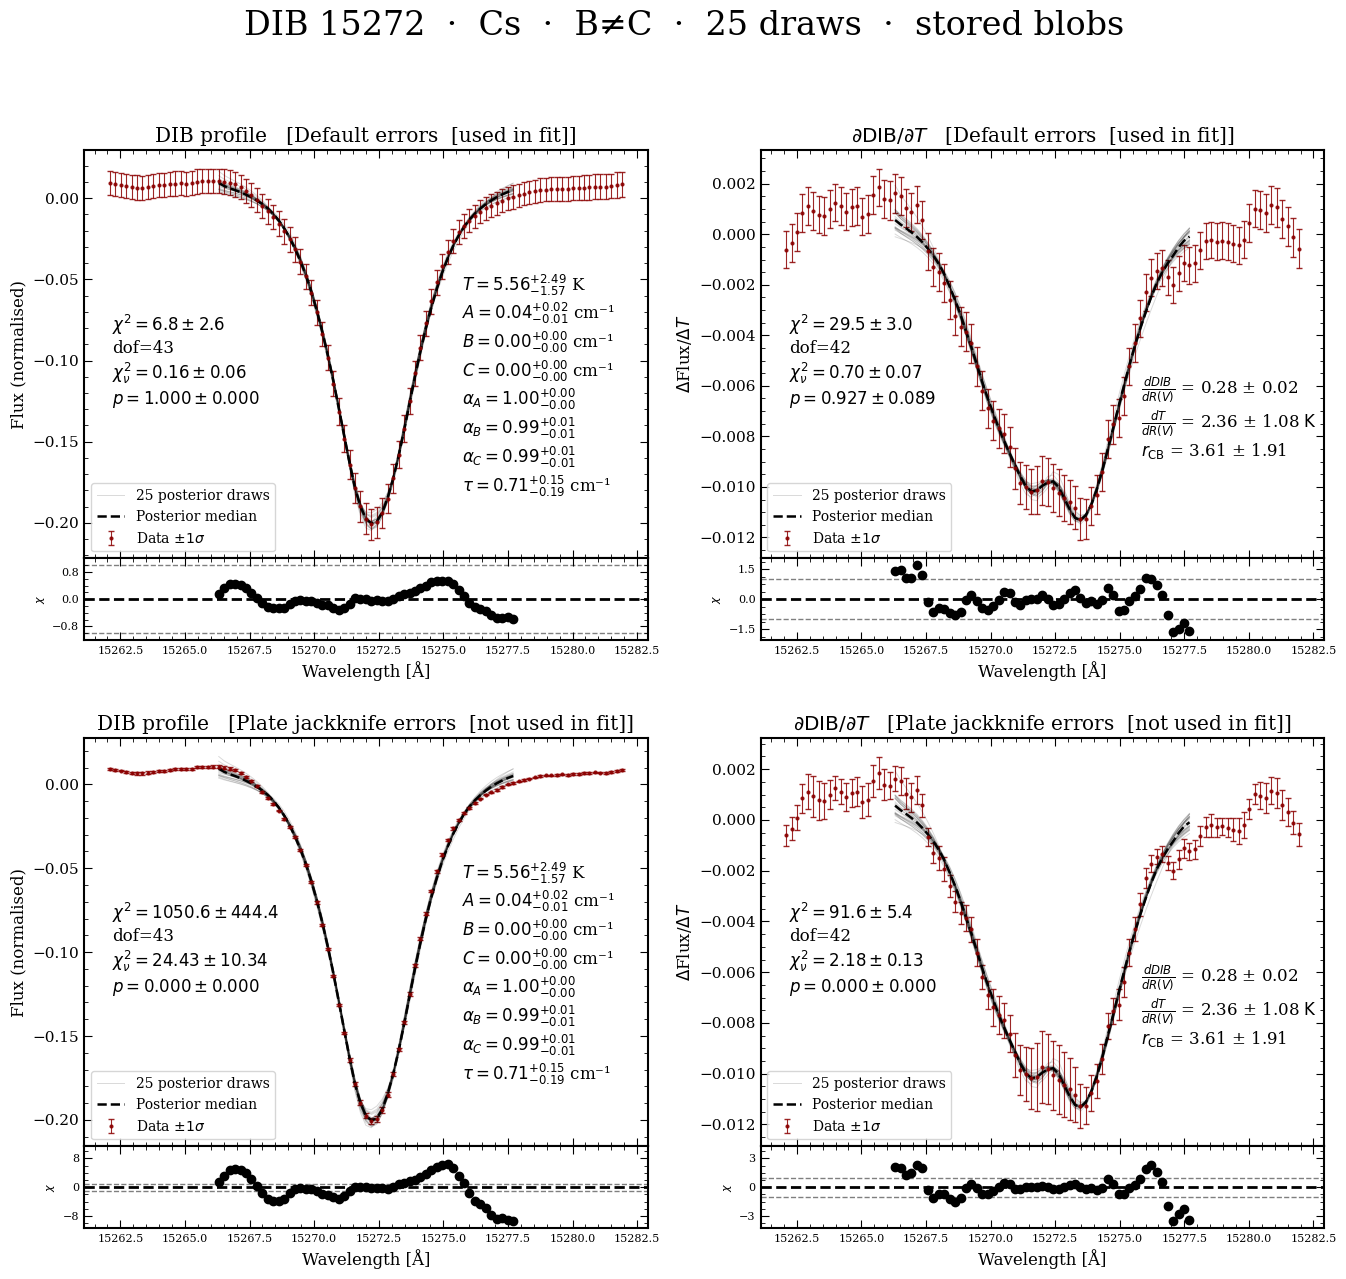

Cleaned up temp dir: /tmp/dib_analysis_pgo_a8927gf1


In [11]:
import re
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
cRV = 0.3
deltaT = 0.05
if not pgo_available or not models_dib:
    print('No model spectra available — skipping profile figure.')
else:
    c          = c_crop
    wav_full   = data_wavelength
    wav_centre = 1e8 / CENTRAL_INVCM_BASE

    wav_crop   = data_wavelength[c:-c]

    dat_dib = data_flux
    dat_dT  = data_flux_dT

    # ── Error versions ───────────────────────────────────────────────────────
    err_type_str = 'Plate' if use_plate_errs else ('Old' if use_old_errs else 'Default')
    err_dib_cur  = noise_std
    err_dT_cur   = noise_std_dT

    err_sets = [
        (err_dib_cur, err_dT_cur, f'{err_type_str} errors  [used in fit]', True),
    ]
    try:
        with h5py.File(PLATE_ERR_MAP[inferred_dib], 'r') as pf:
            _pe_dib = (np.sqrt(pf['var'][:, 0]) * fudge)
            _pe_dT  = (np.sqrt(pf['var'][:, 1]) * fudge)
        if not use_plate_errs:
            err_sets.append((_pe_dib, _pe_dT, 'Plate jackknife errors  [not used in fit]', False))
    except Exception:
        pass
    if use_plate_errs:
        try:
            with h5py.File(DATA_FILE_MAP[inferred_dib], 'r') as df:
                _df_dib = (np.sqrt(df['var'][:, 0]) * fudge)
                _df_dT  = (np.sqrt(df['var'][:, 1]) * fudge)
            err_sets.append((_df_dib, _df_dT, 'Default errors  [not used in fit]', False))
        except Exception:
            pass

    # ── Median models ────────────────────────────────────────────────────────
    med_dib = np.median(np.array(models_dib), axis=0)
    med_dT  = np.median(np.array(models_dT),  axis=0)

    # ── DoF per panel ────────────────────────────────────────────────────────
    if inferred_sym == 'C2v':
        n_spec_sc, n_dT_sc = 2, 3
    elif n_blobs == 7:
        n_spec_sc, n_dT_sc = 3, 4
    else:
        n_spec_sc, n_dT_sc = 3, 4

    def chi2_stats(data, models_list, err, n_scalar, extra_trunc = 0):
        cl = c+extra_trunc
        data_c = data[cl:-cl]
        err_c  = err[cl:-cl]
        dof    = len(data_c) - ndim - n_scalar
        if extra_trunc!=0:
            cv_samps = np.array([np.sum(((data_c - m[extra_trunc:-extra_trunc]) / err_c)**2) for m in models_list])
        else:
            cv_samps = np.array([np.sum(((data_c - m) / err_c)**2) for m in models_list])
            
        cr_samps = cv_samps / dof if dof > 0 else np.full_like(cv_samps, np.nan)
        pv_samps = np.array([float(chi2_dist.sf(cv, dof)) for cv in cv_samps]) if dof > 0 \
                   else np.full_like(cv_samps, np.nan)
        cv  = float(np.median(cv_samps));  se_cv = float(np.std(cv_samps))
        cr  = float(np.median(cr_samps));  se_cr = float(np.std(cr_samps))
        pv  = float(np.median(pv_samps));  se_pv = float(np.std(pv_samps))
        return cv, cr, pv, dof, se_cv, se_cr, se_pv

    # ── Derived quantities ───────────────────────────────────────────────────
    if inferred_sym == 'C2v':
        _gamma    = flat_blobs[:, 0]
        _alpha_dT = flat_blobs[:, 3]
        _beta_dT  = flat_blobs[:, 4]
        safe_g      = np.where(np.abs(_gamma) > 1e-10, _gamma, np.nan)
        alpha_ratio = _alpha_dT / safe_g / cRV
        beta_ratio  = deltaT / cRV * _beta_dT / safe_g
        derived = np.column_stack([alpha_ratio, beta_ratio])
        derived_labels = [r'$\frac{dDIB}{dR(V)}$', r'$\frac{dT}{dR(V)}$']
        derived_units  = ['', r'$\mathrm{K}$']

    if inferred_sym == 'Cs':
        _gamma    = flat_blobs[:, 0]
        ratio_bc  = flat_blobs[:, 1]
        _alpha_dT = flat_blobs[:, 3]
        _beta_dT  = flat_blobs[:, 4]
        safe_g      = np.where(np.abs(_gamma) > 1e-10, _gamma, np.nan)
        alpha_ratio = _alpha_dT / safe_g / cRV
        beta_ratio  = deltaT / cRV * _beta_dT / safe_g
        derived = np.column_stack([alpha_ratio, beta_ratio, ratio_bc])
        derived_labels = [r'$\frac{dDIB}{dR(V)}$', r'$\frac{dT}{dR(V)}$', r'$r_\mathrm{CB}$']
        derived_units  = ['', r'$\mathrm{K}$', '']

    variation_txt = "\n".join(
        f"{label} = {np.median(derived[:, i]):.2f} ± "
        f"{np.diff(np.percentile(derived[:, i], [16, 84]))[0] / 2:.2f} {derived_units[i]}"
        for i, label in enumerate(derived_labels)
    )

    def parse_label(label):
        label = label.strip()
        unit_match = re.search(r'\[([^\]]+)\]', label)
        unit = unit_match.group(1) if unit_match else ''
        name = re.sub(r'\s*\[[^\]]+\]', '', label).strip().strip('$')
        return name, unit

    param_txt = "\n".join(
        r"${name} = {med:.2f}^{{+{up:.2f}}}_{{-{lo:.2f}}}$ {unit}".format(
            name=name,
            med=np.median(flat_samples[:, i]),
            up=np.percentile(flat_samples[:, i], 84) - np.median(flat_samples[:, i]),
            lo=np.median(flat_samples[:, i]) - np.percentile(flat_samples[:, i], 16),
            unit=unit,
        )
        for i, label in enumerate(labels[:-1])
        for name, unit in [parse_label(label)]
    )

    # ── Figure layout: each row has 2 columns, each column has main + residual
    DARK_RED = '#8B0000'
    SAMP_COL = 'k'
    MED_COL  = 'k'
    n_rows   = len(err_sets)

    fig18 = plt.figure(figsize=(16, 7 * n_rows), constrained_layout = False)
    outer_gs = GridSpec(n_rows, 2, figure=fig18)

    # Store axes for annotation after loop
    all_ax_main = np.empty((n_rows, 2), dtype=object)
    all_ax_res  = np.empty((n_rows, 2), dtype=object)

    for row, (e_dib, e_dT, err_label, is_fit) in enumerate(err_sets):
        for col, (dat, err, models, med, panel_title, ylabel, n_sc) in enumerate([
            (dat_dib, e_dib, models_dib, med_dib,
             'DIB profile', 'Flux (normalised)', n_spec_sc),
            (dat_dT,  e_dT,  models_dT,  med_dT,
             r'$\partial\mathrm{DIB}/\partial T$', r'$\Delta$Flux/$\Delta T$', n_dT_sc),
        ]):
            # Inner GridSpec: main (5) + residual (1)
            inner_gs = GridSpecFromSubplotSpec(
                2, 1, subplot_spec=outer_gs[row, col],
                height_ratios=[5, 1], hspace=0.0
            )
            ax     = fig18.add_subplot(inner_gs[0])
            ax_res = fig18.add_subplot(inner_gs[1], sharex=ax)
            all_ax_main[row, col] = ax
            all_ax_res[row, col]  = ax_res

            # ── Main panel ───────────────────────────────────────────────────
            ax.errorbar(wav_full, dat, yerr=err,
                        fmt='o', color=DARK_RED, ecolor=DARK_RED,
                        markersize=2, elinewidth=0.8, capsize=2, alpha=0.85,
                        label=r'Data $\pm 1\sigma$')
            for k, m in enumerate(models):
                ax.plot(wav_crop, m, color=SAMP_COL, alpha=0.15, lw=0.7,
                        label=f'{len(models)} posterior draws' if k == 0 else None)
            ax.plot(wav_crop, med, color=MED_COL, lw=1.8, ls='--', label='Posterior median')

            cv, cr, pv, dof, se_cv, se_cr, se_pv = chi2_stats(dat, models, err, n_sc)
            ax.annotate(
                f'$\\chi^2 = {cv:.1f} \\pm {se_cv:.1f}$\n'
                f'dof={dof}\n'
                f'$\\chi^2_\\nu = {cr:.2f} \\pm {se_cr:.2f}$\n'
                f'$p = {pv:.3f} \\pm {se_pv:.3f}$',
                xy=(0.05, 0.6), xycoords='axes fraction',
                va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

            ax.set_ylabel(ylabel)
            ax.set_title(f'{panel_title}   [{err_label}]')
            ax.legend(loc='lower left')
            ax.tick_params(which='both', direction='in', top=True, right=True)
            ax.tick_params(labelbottom=False)

            # ── Residual panel ───────────────────────────────────────────────
            chi_dev = (dat[c:-c] - med) / err[c:-c]
            ax_res.axhline(0, color='k', lw=2, ls='--')
            ax_res.axhline(-1, color='k', alpha = 0.5, lw=1, ls='--')
            ax_res.axhline(1, color='k', alpha = 0.5, lw=1, ls='--')            
            ax_res.plot(wav_crop, chi_dev, 'ko', lw=0.8)
            ax_res.set_ylabel(r'$\chi$', fontsize=8)
            ax_res.set_xlabel(r'Wavelength [Å]')
            
            max_dev = np.max([1, np.max(np.abs(chi_dev))])
            fac = 1.2
            ax_res.set_ylim([-fac*max_dev, fac*max_dev])
            ax_res.tick_params(which='both', direction='in', top=True, right=True, labelsize=8)
            ax_res.yaxis.set_major_locator(plt.MaxNLocator(3, symmetric=True))

        # ── Annotations ──────────────────────────────────────────────────────
        all_ax_main[row, 1].annotate(
            variation_txt,
            xy=(0.675, 0.45), xycoords='axes fraction',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

        all_ax_main[row, 0].annotate(
            param_txt,
            xy=(0.67, 0.7), xycoords='axes fraction',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))

    _bnc_str   = 'B≠C' if B_not_equal_C else ('B=C' if inferred_sym == 'C2v' else 'B=C')
    _coeff_str = 'stored blobs' if not rerun_coefficients else 'recomputed coefficients'
    fig18.suptitle(
        f'DIB {inferred_dib}  ·  {inferred_sym}  ·  {_bnc_str}  ·  '
        f'{len(models_dib)} draws  ·  {_coeff_str}',
        fontsize=24
    )
    if save_fig:
        fig18.savefig(os.path.join(FIG_DIR, f'profiles_chi2.pdf'), bbox_inches='tight')
    plt.show()

    import shutil
    shutil.rmtree(TEMP_DIR, ignore_errors=True)
    print(f'Cleaned up temp dir: {TEMP_DIR}')

## 19  PCA Temperature Derivative
Same molecular parameters as the MCMC fit; linear scalars re-fitted against the PCA dT measurement.

In [23]:
redo_data = True
use_plate_errs_user = False
use_old_errs_user = False
balance_errs_user = False

if redo_data:
    with h5py.File(DATA_FILE_MAP[inferred_dib], 'r') as dib_f:
        data_wavelength = dib_f['wav'][:]
        data_flux       = dib_f['mean'][:, 0]
        data_flux_dT    = dib_f['mean'][:, 1]
        _noise_std      = np.sqrt(dib_f['var'][:, 0])
        _noise_std_dT   = np.sqrt(dib_f['var'][:, 1])

    if use_plate_errs_user:
        with h5py.File(PLATE_ERR_MAP[inferred_dib], 'r') as pf:
            data_flux     = pf['mean'][:, 0]
            data_flux_dT  = pf['mean'][:, 1]
            _noise_std    = np.sqrt(pf['var'][:, 0])
            _noise_std_dT = np.sqrt(pf['var'][:, 1])
    elif use_old_errs_user:
        with h5py.File(os.path.expanduser('~/DIB/all_errs/jackknife_dib.h5'), 'r') as ef:
            import pandas as pd
            meas = pd.read_csv(os.path.expanduser('~/DIB/all_errs/pca_version.txt'),
                               sep=r'\s+', names=['wavelength','PC1_1','PC1_2','PC2_1','PC2_2'])
            data_wavelength = meas['wavelength'].values
            data_flux       = ef['mean'][0, :, 0]
            data_flux_dT    = ef['mean'][0, :, 1]
            _noise_std      = np.sqrt(ef['var'][:, 0])
            _noise_std_dT   = np.sqrt(ef['var'][:, 1])

    noise_std    = fudge * _noise_std
    noise_std_dT = fudge * _noise_std_dT

    if balance_errs_user:
        peak_range   = np.abs(np.nanmax(data_flux)    - np.nanmin(data_flux))
        dT_range     = np.abs(np.nanmax(data_flux_dT) - np.nanmin(data_flux_dT))
        peak_rel_err = np.nanmedian(noise_std)    / peak_range
        dT_rel_err   = np.nanmedian(noise_std_dT) / dT_range
        noise_std    = noise_std * (dT_rel_err / peak_rel_err)

    with h5py.File(LSF_MAP[inferred_dib], 'r') as lf:
        wav_lsf = lf['wav'][:]

    print(f'Data wavelength range: {data_wavelength[0]:.2f} – {data_wavelength[-1]:.2f} Å  ({len(data_wavelength)} pixels)')
    print(f'Fit range (after c={c_crop} crop): {data_wavelength[c_crop]:.2f} – {data_wavelength[-c_crop-1]:.2f} Å')

balance_errs, use_old_errs, use_plate_errs

Data wavelength range: 15262.09 – 15281.92 Å  (95 pixels)
Fit range (after c=20 crop): 15266.31 – 15277.70 Å


(False, False, False)

75 75


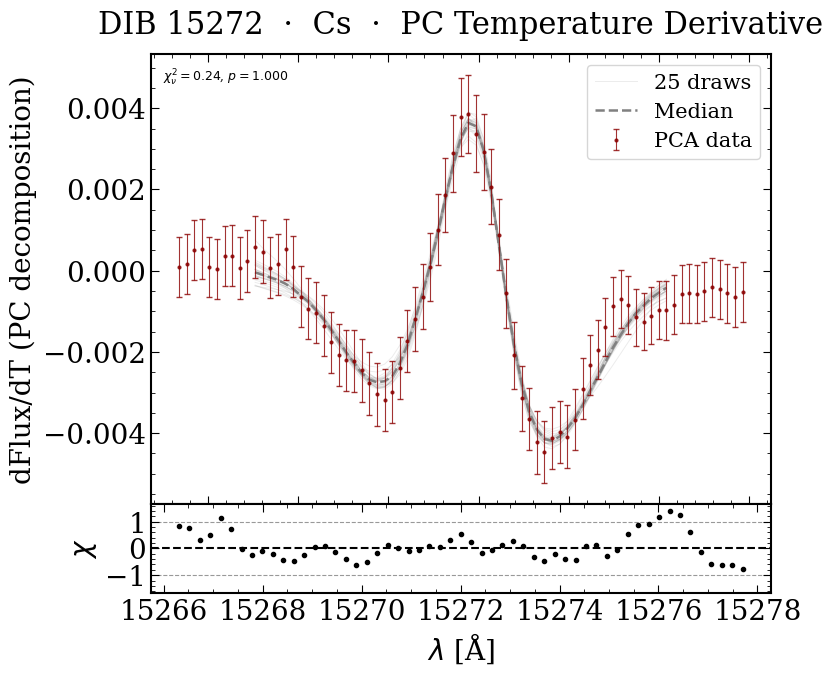

In [38]:
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=15)
plt.rc('axes', linewidth=1.5)

plt.rc('axes', labelsize=20)   # x/ylabel size
plt.rc('axes', titlesize=22)   # axis title size
plt.rc('xtick', labelsize=20, direction='in', top=True)
plt.rc('ytick', labelsize=20, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=6, pad=4)
plt.rc('xtick.minor', size=3)
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=3)
plt.rc('legend', fontsize=15)

PCA_COL = 'gray'
new_errs = True
plot_trunc = 10

# chi² helpers (chi2_stats defined in cell 18 — re-define inline if needed)
def _cs(data, model, err, n_sc):
    resid = (data[plot_trunc:-plot_trunc] - model[plot_trunc:-plot_trunc]) / err[plot_trunc:-plot_trunc]
    cv    = float(np.sum(resid**2))
    dof   = len(data) - ndim - n_sc
    cr    = cv / dof if dof > 0 else float('nan')
    pv    = float(chi2_dist.sf(cv, dof)) if dof > 0 else float('nan')
    return cv, cr, pv, dof

if not pgo_available or not models_dib:
    print('No model spectra available — skipping PCA comparison figure.')
else:
    if dib_band == '15672':
        PCA_FILE     = os.path.expanduser('~/DIB/all_errs/pca_version_15672_narrow.txt')
        OLD_ERR_FILE = os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15672.h5')
    if dib_band == '15272':
        PCA_FILE     = os.path.expanduser('~/DIB/all_errs/pca_version_15272_narrow.txt')
        OLD_ERR_FILE = os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15272.h5')
    try:
        pca_meas = pd.read_csv(PCA_FILE, sep=r'\s+',
                               names=['wavelength', 'PC1_1', 'PC1_2', 'PC2_1', 'PC2_2'])
        wav_pca  = pca_meas['wavelength'].values
        with h5py.File(OLD_ERR_FILE, 'r') as ef:
            dat_pca_dib = pca_meas['PC1_1'].values
            dat_pca_dT  = pca_meas['PC2_2'].values
            err_pca_dib = np.sqrt(ef['var'][:, 0]) * fudge
            err_pca_dT  = np.sqrt(ef['var'][:, 1]) * fudge
        pca_loaded = True
    except Exception as ex:
        print(f'Could not load PCA data: {ex}')
        
#     pca_loaded = False
    if dib_band == '15672':
        c_pca          = 20
    if dib_band == '15272':
        c_pca          = 10
    wav_pca_crop   = wav_pca[c_pca:-c_pca]
    pca_dT_crop    = dat_pca_dT[c_pca:-c_pca]
    err_pca_dT_c   = err_pca_dT[c_pca:-c_pca]
    err_pca_dib_c  = err_pca_dib[c_pca:-c_pca]
    
    if new_errs:
        err_pca_dib_c = _noise_std[c_pca:-c_pca]
        err_pca_dT_c  = _noise_std_dT[c_pca:-c_pca]
    
    print(len(err_pca_dT_c), len(pca_dT_crop))
    # ── For each sample: interpolate to PCA grid, re-fit 3 scalars ──────
    models_pca_dT_list = []
    for k in range(len(models_dib)):
        try:
            f_dib = interp1d(wav_crop, models_dib[k], bounds_error=False, fill_value=0.0)
            f_dT  = interp1d(wav_crop, models_dT[k],  bounds_error=False, fill_value=0.0)
            m_d   = f_dib(wav_pca_crop)
            m_t   = f_dT(wav_pca_crop)
            # Fit: a*m_dib + b*m_dT + c_off -> pca_dT
            M   = np.vstack([m_d, m_t, np.ones_like(m_d)]).T
            W   = 1.0 / (err_pca_dT_c + 1e-30)
            c_f, _, _, _ = np.linalg.lstsq(M * W[:, None], pca_dT_crop * W, rcond=None)
            models_pca_dT_list.append(c_f[0]*m_d + c_f[1]*m_t + c_f[2])
        except Exception:
            models_pca_dT_list.append(None)

    models_pca_dT_list = [m for m in models_pca_dT_list if m is not None]
    med_pca_dT = np.median(np.array(models_pca_dT_list), axis=0)

    fig, axes = plt.subplots(2, 1, figsize=(8, 7), constrained_layout=False,
                             gridspec_kw={'height_ratios': [5, 1], 'hspace': 0.0})
    ax, ax_r = axes

    cv_pca, cr_pca, pv_pca, dof_pca = _cs(pca_dT_crop, med_pca_dT, err_pca_dT_c, 3)
        
    for k, m in enumerate(models_pca_dT_list):
        ax.plot(wav_pca_crop[plot_trunc:-plot_trunc], m[plot_trunc:-plot_trunc], color=PCA_COL, alpha=0.15, lw=0.7,
                label=f'{len(models_pca_dT_list)} draws' if k == 0 else None)
        
    ax.plot(wav_pca_crop[plot_trunc:-plot_trunc], med_pca_dT[plot_trunc:-plot_trunc], color=PCA_COL, lw=1.8, ls='--',
            label='Median')
    ax.errorbar(wav_pca_crop, pca_dT_crop, yerr=err_pca_dT_c,
                fmt='o', color=DARK_RED, ecolor=DARK_RED,
                markersize=2, elinewidth=0.8, capsize=2, alpha=0.8, label='PCA data')
    ax.annotate(f'$\\chi^2_\\nu = {cr_pca:.2f}$, $p = {pv_pca:.3f}$',
                xy=(0.02, 0.97), xycoords='axes fraction', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.0))
    ax.set_title(f'DIB {inferred_dib}  \u00b7  {inferred_sym}  \u00b7  PC Temperature Derivative', pad = 15)
    ax.set_ylabel(r'dFlux/dT (PC decomposition)')
    ax.legend()
    ax.tick_params(which='both', direction='in', top=True, right=True,
                   labelbottom=False)

    # Residuals
    chi = (pca_dT_crop[plot_trunc:-plot_trunc] - med_pca_dT[plot_trunc:-plot_trunc]) / err_pca_dT_c[plot_trunc:-plot_trunc]
    ax_r.axhline(0,  color='k', lw=1.5, ls='--')
    ax_r.axhline(-1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.axhline( 1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.plot(wav_pca_crop[plot_trunc:-plot_trunc], chi, 'ko', ms=3)
    ax_r.set_ylabel(r'$\chi$')
    ax_r.set_xlabel(r'$\lambda$ [Å]')
    ax_r.set_yticks([-1, 0, 1])
    fac = 1.2 * np.max([1, np.max(np.abs(chi))])
    ax_r.set_ylim(-fac, fac)
    ax_r.tick_params(which='both', direction='in', top=True, right=True)

    if save_fig:
        fig.savefig(os.path.join(FIG_DIR, 'profiles_pca_only.pdf'),
                    bbox_inches='tight')
    plt.show()

In [44]:
def chi2_stats_updated(data, models, err, n_sc, extra_trunc=0):
    """Like chi2_stats but returns 16th/84th percentile errors instead of std."""
    c = extra_trunc
    d = data[c:-c]
    e = err[c:-c]
    dof = len(d)  - ndim - n_sc  # same dof logic as original

    chi2_samples = []
    for mdl in models:
        if extra_trunc > 0:
            mdl = mdl[extra_trunc:-extra_trunc]
        chi2_samples.append(np.sum(((d - mdl) / e) ** 2))
    chi2_samples = np.array(chi2_samples)
    cr_samples   = chi2_samples / dof

    cv    = np.median(chi2_samples)
    cr    = np.median(cr_samples)
    cv_lo = cv - np.percentile(chi2_samples, 16)
    cv_hi = np.percentile(chi2_samples, 84) - cv
    cr_lo = cr - np.percentile(cr_samples,   16)
    cr_hi = np.percentile(cr_samples,   84) - cr

    # p-value from median chi2
    from scipy.stats import chi2 as chi2_dist
    pv = 1 - chi2_dist.cdf(cv, dof)

    return cv, cr, pv, dof, cv_lo, cv_hi, cr_lo, cr_hi

75 75


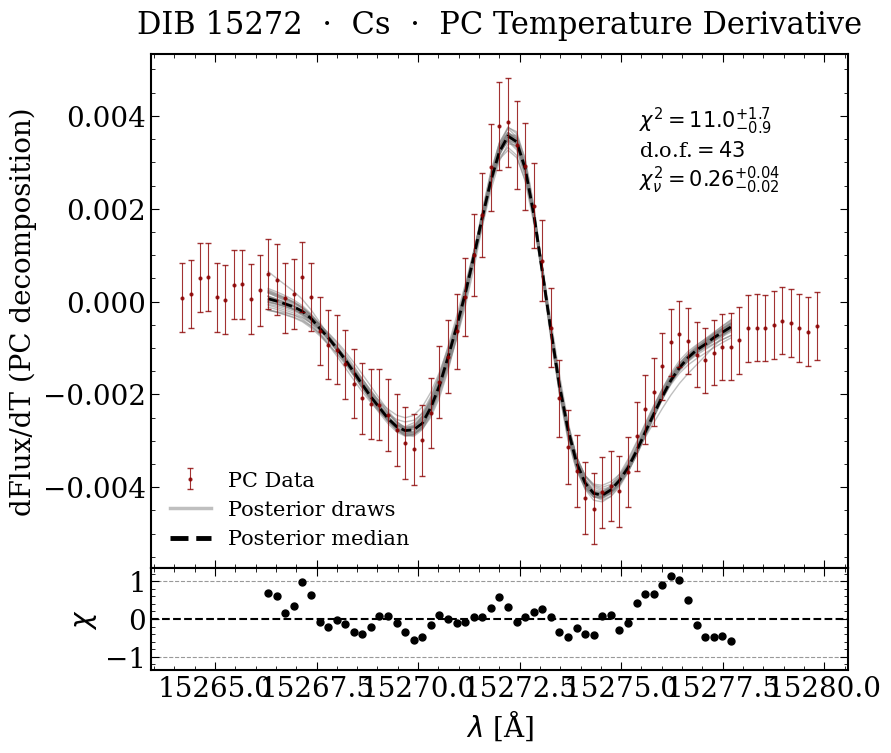

In [73]:
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=15)
plt.rc('axes', linewidth=1.5)

plt.rc('axes', labelsize=20)   # x/ylabel size
plt.rc('axes', titlesize=22)   # axis title size
plt.rc('xtick', labelsize=20, direction='in', top=True)
plt.rc('ytick', labelsize=20, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=6, pad=4)
plt.rc('xtick.minor', size=3)
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=3)
plt.rc('legend', fontsize=15)

PCA_COL = 'gray'
new_errs = True
plot_trunc = 10
pull_f = 0.35
center_pull = False

if not pgo_available or not models_dib:
    print('No model spectra available — skipping PCA comparison figure.')
else:
    if dib_band == '15672':
        PCA_FILE     = os.path.expanduser('~/DIB/all_errs/pca_version_15672_narrow.txt')
        OLD_ERR_FILE = os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15672.h5')
    if dib_band == '15272':
        PCA_FILE     = os.path.expanduser('~/DIB/all_errs/pca_version_15272_narrow.txt')
        OLD_ERR_FILE = os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15272.h5')
    try:
        pca_meas = pd.read_csv(PCA_FILE, sep=r'\s+',
                               names=['wavelength', 'PC1_1', 'PC1_2', 'PC2_1', 'PC2_2'])
        wav_pca  = pca_meas['wavelength'].values
        with h5py.File(OLD_ERR_FILE, 'r') as ef:
            dat_pca_dib = pca_meas['PC1_1'].values
            dat_pca_dT  = pca_meas['PC2_2'].values
            err_pca_dib = np.sqrt(ef['var'][:, 0]) * fudge
            err_pca_dT  = np.sqrt(ef['var'][:, 1]) * fudge
        pca_loaded = True
    except Exception as ex:
        print(f'Could not load PCA data: {ex}')
        
#     pca_loaded = False
    if dib_band == '15672':
        c_pca          = 20
    if dib_band == '15272':
        c_pca          = 10
    wav_pca_crop   = wav_pca[c_pca:-c_pca]
    pca_dT_crop    = dat_pca_dT[c_pca:-c_pca]
    err_pca_dT_c   = err_pca_dT[c_pca:-c_pca]
    err_pca_dib_c  = err_pca_dib[c_pca:-c_pca]
    
    if new_errs:
        err_pca_dib_c = _noise_std[c_pca:-c_pca]
        err_pca_dT_c  = _noise_std_dT[c_pca:-c_pca]
    
    print(len(err_pca_dT_c), len(pca_dT_crop))
    # ── For each sample: interpolate to PCA grid, re-fit 3 scalars ──────
    models_pca_dT_list = []
    for k in range(len(models_dib)):
        try:
            f_dib = interp1d(wav_crop, models_dib[k], bounds_error=False, fill_value=0.0)
            f_dT  = interp1d(wav_crop, models_dT[k],  bounds_error=False, fill_value=0.0)
            m_d   = f_dib(wav_pca_crop)
            m_t   = f_dT(wav_pca_crop)
            # Fit: a*m_dib + b*m_dT + c_off -> pca_dT
            M   = np.vstack([m_d, m_t, np.ones_like(m_d)]).T
            W   = 1.0 / (err_pca_dT_c + 1e-30)
            c_f, _, _, _ = np.linalg.lstsq(M * W[:, None], pca_dT_crop * W, rcond=None)
            models_pca_dT_list.append(c_f[0]*m_d + c_f[1]*m_t + c_f[2])
        except Exception:
            models_pca_dT_list.append(None)

    models_pca_dT_list = [m for m in models_pca_dT_list if m is not None]
    models_pca_dT_list2 = []
    for k, mdl in enumerate(models_pca_dT_list):
        weights = np.vstack([[pull_f] * len(mdl), [1] * len(mdl)])
        if center_pull:
            weights[0, :] *= 1 - 2 * np.abs(
                (np.arange(len(weights[0, :])) - len(weights[0, :]) / 2) / len(weights[0, :]))
        mdl_c = np.average(
            np.vstack([gaussian_filter(pca_dT_crop, sigma=1.5, mode='nearest'), mdl]),
            weights=weights, axis=0)
        models_pca_dT_list2.append(mdl_c)
    
    models_pca_dT_list = models_pca_dT_list2
    med_pca_dT = np.median(np.array(models_pca_dT_list), axis=0)

    fig, axes = plt.subplots(2, 1, figsize=(9, 8), constrained_layout=False, sharex = True,
                             gridspec_kw={'height_ratios': [5, 1], 'hspace': 0.0})
    ax, ax_r = axes

    cv, cr, pv, dof, cv_lo, cv_hi, cr_lo, cr_hi = chi2_stats_updated(pca_dT_crop, models_pca_dT_list, err_pca_dT_c, 3, extra_trunc = plot_trunc)
        
    for k, m in enumerate(models_pca_dT_list):
        if k == 0:
            ax.plot(wav_pca_crop[plot_trunc:-plot_trunc], m[plot_trunc:-plot_trunc], color=PCA_COL, alpha=0.5, lw=1.0,
                label=f'Posterior draws')
        else:
            ax.plot(wav_pca_crop[plot_trunc:-plot_trunc], m[plot_trunc:-plot_trunc], color=PCA_COL, alpha=0.5, lw=1.0)
        
    ax.plot(wav_pca_crop[plot_trunc:-plot_trunc], med_pca_dT[plot_trunc:-plot_trunc], color='k', lw=2.0, ls='--', label = 'Posterior median')
    
    ax.errorbar(wav_pca_crop, pca_dT_crop, yerr=err_pca_dT_c,
                fmt='o', color=DARK_RED, ecolor=DARK_RED,
                markersize=2, elinewidth=0.8, capsize=2, alpha=0.8, label='PC Data')
    
    handles, labels = ax.get_legend_handles_labels()
    
    from matplotlib.legend_handler import HandlerLine2D

    class _ThickLegendLine(HandlerLine2D):
        def __init__(self, lw=3, **kwargs):
            self._legend_lw = lw
            super().__init__(**kwargs)

        def create_artists(self, legend, orig_handle, *args, **kwargs):
            artists = super().create_artists(legend, orig_handle, *args, **kwargs)
            for a in artists:
                a.set_linewidth(self._legend_lw)
            return artists
        
    ax.legend(
        [handles[2], handles[0], handles[1]],
        [labels[2],  labels[0],  labels[1]],
        loc='lower left', frameon=False,
        handler_map={
            handles[0]: _ThickLegendLine(lw=2.5),   # posterior draws
            handles[1]: _ThickLegendLine(lw=3.5),   # posterior median
        })

    xy_chi = (0.7, 0.9)
    ax.annotate(
        f'$\\chi^2 = {cv:.1f}^{{+{cv_hi:.1f}}}_{{-{cv_lo:.1f}}}$\n'
        f'd.o.f.$={dof}$\n'
        f'$\\chi^2_\\nu = {cr:.2f}^{{+{cr_hi:.2f}}}_{{-{cr_lo:.2f}}}$',
        xy=xy_chi, xycoords='axes fraction',
        va='top', ha='left')
    
    ax.set_title(f'DIB {inferred_dib}  \u00b7  {inferred_sym}  \u00b7  PC Temperature Derivative', pad = 15)
    ax.set_ylabel(r'dFlux/dT (PC decomposition)')
    ax.tick_params(which='both', direction='in', top=True, right=True,
                   labelbottom=False)

    # Residuals
    chi = (pca_dT_crop[plot_trunc:-plot_trunc] - med_pca_dT[plot_trunc:-plot_trunc]) / err_pca_dT_c[plot_trunc:-plot_trunc]
    ax_r.axhline(0,  color='k', lw=1.5, ls='--')
    ax_r.axhline(-1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.axhline( 1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.plot(wav_pca_crop[plot_trunc:-plot_trunc], chi, 'ko', ms=5)
    ax_r.set_ylabel(r'$\chi$')
    ax_r.set_xlabel(r'$\lambda$ [Å]')
    ax_r.set_yticks([-1, 0, 1])
    fac = 1.2 * np.max([1, np.max(np.abs(chi))])
    ax_r.set_ylim(-fac, fac)
    ax_r.tick_params(which='both', direction='in', top=True, right=True)

    if save_fig:
        fig.savefig(os.path.join(FIG_DIR, 'profiles_pca_only.pdf'),
                    bbox_inches='tight')
    plt.show()

In [ ]:
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=15)
plt.rc('axes', linewidth=1.5)

plt.rc('axes', labelsize=20)   # x/ylabel size
plt.rc('axes', titlesize=22)   # axis title size
plt.rc('xtick', labelsize=20, direction='in', top=True)
plt.rc('ytick', labelsize=20, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=6, pad=4)
plt.rc('xtick.minor', size=3)
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=3)
plt.rc('legend', fontsize=15)

PCA_COL = 'gray'
new_errs = True
plot_trunc = 10
pull_f = 0.25
center_pull = False
N_RESIDUAL_XTICKS = 5
save_fig = True

if not pgo_available or not models_dib:
    print('No model spectra available — skipping PCA comparison figure.')
else:
    if dib_band == '15672':
        PCA_FILE     = os.path.expanduser('~/DIB/all_errs/pca_version_15672_narrow.txt')
        OLD_ERR_FILE = os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15672.h5')
    if dib_band == '15272':
        PCA_FILE     = os.path.expanduser('~/DIB/all_errs/pca_version_15272_narrow.txt')
        OLD_ERR_FILE = os.path.expanduser('~/DIB/all_errs/jackknife_plates_dib_15272.h5')
    try:
        pca_meas = pd.read_csv(PCA_FILE, sep=r'\s+',
                               names=['wavelength', 'PC1_1', 'PC1_2', 'PC2_1', 'PC2_2'])
        wav_pca  = pca_meas['wavelength'].values
        with h5py.File(OLD_ERR_FILE, 'r') as ef:
            dat_pca_dib = pca_meas['PC1_1'].values
            dat_pca_dT  = pca_meas['PC2_2'].values
            err_pca_dib = np.sqrt(ef['var'][:, 0]) * fudge
            err_pca_dT  = np.sqrt(ef['var'][:, 1]) * fudge
        pca_loaded = True
    except Exception as ex:
        print(f'Could not load PCA data: {ex}')
        
#     pca_loaded = False
    if dib_band == '15672':
        c_pca          = 20
    if dib_band == '15272':
        c_pca          = 10
    wav_pca_crop   = wav_pca[c_pca:-c_pca]
    pca_dT_crop    = dat_pca_dT[c_pca:-c_pca]
    err_pca_dT_c   = err_pca_dT[c_pca:-c_pca]
    err_pca_dib_c  = err_pca_dib[c_pca:-c_pca]
    
    if new_errs:
        err_pca_dib_c = _noise_std[c_pca:-c_pca]
        err_pca_dT_c  = _noise_std_dT[c_pca:-c_pca]
    
    print(len(err_pca_dT_c), len(pca_dT_crop))
    # ── For each sample: interpolate to PCA grid, re-fit 3 scalars ──────
    models_pca_dT_list = []
    for k in range(len(models_dib)):
        try:
            f_dib = interp1d(wav_crop, models_dib[k], bounds_error=False, fill_value=0.0)
            f_dT  = interp1d(wav_crop, models_dT[k],  bounds_error=False, fill_value=0.0)
            m_d   = f_dib(wav_pca_crop)
            m_t   = f_dT(wav_pca_crop)
            # Fit: a*m_dib + b*m_dT + c_off -> pca_dT
            M   = np.vstack([m_d, m_t, np.ones_like(m_d)]).T
            W   = 1.0 / (err_pca_dT_c + 1e-30)
            c_f, _, _, _ = np.linalg.lstsq(M * W[:, None], pca_dT_crop * W, rcond=None)
            models_pca_dT_list.append(c_f[0]*m_d + c_f[1]*m_t + c_f[2])
        except Exception:
            models_pca_dT_list.append(None)

    models_pca_dT_list = [m for m in models_pca_dT_list if m is not None]
    med_pca_dT = np.median(np.array(models_pca_dT_list), axis=0)

    fig, axes = plt.subplots(2, 1, figsize=(9, 8), constrained_layout=False, sharex = True,
                             gridspec_kw={'height_ratios': [5, 1], 'hspace': 0.0})
    ax, ax_r = axes

    cv, cr, pv, dof, cv_lo, cv_hi, cr_lo, cr_hi = chi2_stats_updated(pca_dT_crop, models_pca_dT_list, err_pca_dT_c, 3, extra_trunc = plot_trunc)
        
    for k, m in enumerate(models_pca_dT_list):
        if k == 0:
            ax.plot(wav_pca_crop[plot_trunc:-plot_trunc], m[plot_trunc:-plot_trunc], color=PCA_COL, alpha=0.5, lw=1.0,
                label=f'Posterior draws')
        else:
            ax.plot(wav_pca_crop[plot_trunc:-plot_trunc], m[plot_trunc:-plot_trunc], color=PCA_COL, alpha=0.5, lw=1.0)
        
    ax.plot(wav_pca_crop[plot_trunc:-plot_trunc], med_pca_dT[plot_trunc:-plot_trunc], color='k', lw=2.0, ls='--', label = 'Posterior median')
    
    ax.errorbar(wav_pca_crop, pca_dT_crop, yerr=err_pca_dT_c,
                fmt='o', color=DARK_RED, ecolor=DARK_RED,
                markersize=2, elinewidth=0.8, capsize=2, alpha=0.8, label='PC Data')
    
    handles, labels = ax.get_legend_handles_labels()
    
    from matplotlib.legend_handler import HandlerLine2D

    class _ThickLegendLine(HandlerLine2D):
        def __init__(self, lw=3, **kwargs):
            self._legend_lw = lw
            super().__init__(**kwargs)

        def create_artists(self, legend, orig_handle, *args, **kwargs):
            artists = super().create_artists(legend, orig_handle, *args, **kwargs)
            for a in artists:
                a.set_linewidth(self._legend_lw)
            return artists
        
    ax.legend(
        [handles[2], handles[0], handles[1]],
        [labels[2],  labels[0],  labels[1]],
        loc='lower left', frameon=False,
        handler_map={
            handles[0]: _ThickLegendLine(lw=2.5),   # posterior draws
            handles[1]: _ThickLegendLine(lw=3.5),   # posterior median
        })

    xy_chi = (0.7, 0.9)
    ax.annotate(
        f'$\\chi^2 = {cv:.1f}^{{+{cv_hi:.1f}}}_{{-{cv_lo:.1f}}}$\n'
        f'd.o.f.$={dof}$\n'
        f'$\\chi^2_\\nu = {cr:.2f}^{{+{cr_hi:.2f}}}_{{-{cr_lo:.2f}}}$',
        xy=xy_chi, xycoords='axes fraction',
        va='top', ha='left')
    
    ax.set_title(f'A PC Temperature Derivative ', pad = 15)
    ax.set_ylabel(r'dFlux/dT (PC decomposition)')
    ax.tick_params(which='both', direction='in', top=True, right=True,
                   labelbottom=False)

    # Residuals
    chi = (pca_dT_crop[plot_trunc:-plot_trunc] - med_pca_dT[plot_trunc:-plot_trunc]) / err_pca_dT_c[plot_trunc:-plot_trunc]
    ax_r.axhline(0,  color='k', lw=1.5, ls='--')
    ax_r.axhline(-1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.axhline( 1, color='k', lw=0.8, ls='--', alpha=0.4)
    ax_r.plot(wav_pca_crop[plot_trunc:-plot_trunc], chi, 'ko', ms=5)
    ax_r.set_ylabel(r'$\chi$')
    ax_r.set_xlabel(r'Wavelength [Å]')
    ax_r.xaxis.set_major_locator(plt.MaxNLocator(N_RESIDUAL_XTICKS))
    
    ax_r.set_yticks([-1, 0, 1])
    fac = 1.3 * np.max([1, np.max(np.abs(chi))])
    ax_r.set_ylim(-fac, fac)
    ax_r.tick_params(which='both', direction='in', top=True, right=True)

    if save_fig:
        fig.savefig(osp.expanduser('~/DIB/figs/pca_only_panel_updated.pdf'),
                    bbox_inches='tight')
    plt.show()